# 02 – Đọc & Xử Lý Ảnh Bằng Pillow

**Mục tiêu:**
- Đọc ảnh bằng `Image.open()`
- Kiểm tra thông tin ảnh: `size`, `mode`, `format`
- Hiểu ý nghĩa của `width` và `height`
- Chuyển đổi định dạng: JPG → PNG và PNG → JPG
- Lưu output vào `data/output/`
- So sánh **Pillow** và **OpenCV**

---

## 0. Cài đặt thư viện (nếu cần)

In [1]:
# Bỏ comment nếu chưa cài
# !pip install Pillow opencv-python matplotlib numpy


## 1. Import & Cấu hình đường dẫn

In [2]:
import sys, os, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Xác định thư mục lab_1 linh hoạt (dù chạy từ notebook/, repo root, hay workspace root)
cwd = Path(os.getcwd()).resolve()
if (cwd / 'data' / 'input').exists() and (cwd / 'src').exists():
    LAB1_DIR = cwd
elif (cwd / 'lab_1' / 'data' / 'input').exists():
    LAB1_DIR = cwd / 'lab_1'
elif (cwd.parent / 'data' / 'input').exists() and (cwd.parent / 'src').exists():
    LAB1_DIR = cwd.parent
else:
    candidates = [p for p in [cwd] + list(cwd.parents) if (p / 'lab_1' / 'data' / 'input').exists()]
    LAB1_DIR = (candidates[0] / 'lab_1') if candidates else cwd.parent

SRC_DIR    = LAB1_DIR / 'src'
INPUT_DIR  = LAB1_DIR / 'data' / 'input'
OUTPUT_DIR = LAB1_DIR / 'data' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from image_io import (
    pillow_open, get_image_info, print_image_info,
    cv2_open, get_cv2_info,
    convert_format_pillow, benchmark_read,
    pil_to_cv2, cv2_to_pil, ensure_output_dir,
)

print(f'LAB1_DIR   : {LAB1_DIR}')
print(f'INPUT_DIR  : {INPUT_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'Pillow  version : {Image.__version__}')
print(f'OpenCV  version : {cv2.__version__}')


LAB1_DIR   : E:\XỬ LÍ THỊ GIÁC MÁY TÍNH\Computer-Vision-Group-2\lab_1
INPUT_DIR  : E:\XỬ LÍ THỊ GIÁC MÁY TÍNH\Computer-Vision-Group-2\lab_1\data\input
OUTPUT_DIR : E:\XỬ LÍ THỊ GIÁC MÁY TÍNH\Computer-Vision-Group-2\lab_1\data\output
Pillow  version : 12.3.0
OpenCV  version : 5.0.0


---
## 2. Đọc ảnh bằng `Image.open()`

In [3]:
SAMPLE_JPG = INPUT_DIR / '01_portrait_grace_hopper.jpg'
img = pillow_open(SAMPLE_JPG)
print(f'Đã mở: {SAMPLE_JPG.name}')
print(f'Kiểu đối tượng: {type(img)}')


Đã mở: 01_portrait_grace_hopper.jpg
Kiểu đối tượng: <class 'PIL.JpegImagePlugin.JpegImageFile'>


---
## 3. Kiểm tra thông tin ảnh: `size`, `mode`, `format`

In [4]:
print('=== Thuộc tính cơ bản (Pillow) ===')
print(f'  img.size   = {img.size}   # (width, height)')
print(f'  img.width  = {img.width}')
print(f'  img.height = {img.height}')
print(f'  img.mode   = {img.mode}')
print(f'  img.format = {img.format}')
print()
print_image_info(img, label=SAMPLE_JPG.name)


=== Thuộc tính cơ bản (Pillow) ===
  img.size   = (512, 600)   # (width, height)
  img.width  = 512
  img.height = 600
  img.mode   = RGB
  img.format = JPEG

=== 01_portrait_grace_hopper.jpg ===
  Format   : JPEG
  Mode     : RGB
  Size     : (512, 600)  ->  width=512px, height=600px
  Channels : 3
  Pixels   : 307,200



### 3.1 Giải thích `width` và `height`

| Thuộc tính | Ý nghĩa | Trục NumPy |
|---|---|---|
| `img.width` | Số cột pixel (chiều ngang) | `axis=1` |
| `img.height` | Số hàng pixel (chiều dọc) | `axis=0` |
| `img.size` | Tuple `(width, height)` | – |

> ⚠️ Khi chuyển sang NumPy: shape = **(height, width, channels)** — ngược với `img.size`!


In [5]:
arr = np.array(img)
print(f'img.size  = {img.size}   -> (width={img.width}, height={img.height})')
print(f'arr.shape = {arr.shape}  -> (height, width, channels)')
print(f'arr.shape[0] == img.height : {arr.shape[0] == img.height}')
print(f'arr.shape[1] == img.width  : {arr.shape[1] == img.width}')


img.size  = (512, 600)   -> (width=512, height=600)
arr.shape = (600, 512, 3)  -> (height, width, channels)
arr.shape[0] == img.height : True
arr.shape[1] == img.width  : True


---
## 4. Hiển thị ảnh

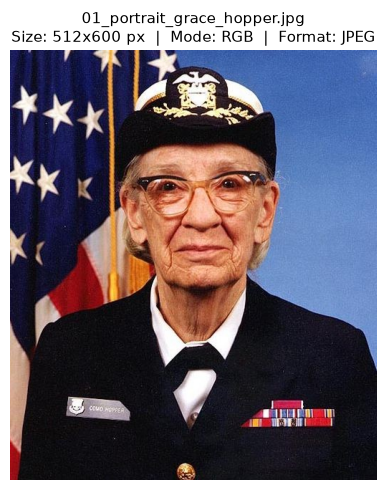

Đã lưu: pillow_sample_display.png


In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img)
title = f'{SAMPLE_JPG.name}\nSize: {img.width}x{img.height} px  |  Mode: {img.mode}  |  Format: {img.format}'
ax.set_title(title, fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pillow_sample_display.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu: pillow_sample_display.png')


---
## 5. Chuyển đổi định dạng

### 5.1 JPG → PNG

In [7]:
src_jpg = SAMPLE_JPG
dst_png = OUTPUT_DIR / (src_jpg.stem + '_converted.png')
out_path = convert_format_pillow(src_jpg, dst_png)
print(f'Đã chuyển đổi: {src_jpg.name} -> {out_path.name}')
print(f'  Kích thước gốc (JPG) : {src_jpg.stat().st_size:>10,} bytes')
print(f'  Kích thước mới (PNG) : {out_path.stat().st_size:>10,} bytes')
img_png = Image.open(out_path)
print_image_info(img_png, label=out_path.name)


Đã chuyển đổi: 01_portrait_grace_hopper.jpg -> 01_portrait_grace_hopper_converted.png
  Kích thước gốc (JPG) :     72,504 bytes
  Kích thước mới (PNG) :    451,602 bytes
=== 01_portrait_grace_hopper_converted.png ===
  Format   : PNG
  Mode     : RGB
  Size     : (512, 600)  ->  width=512px, height=600px
  Channels : 3
  Pixels   : 307,200



### 5.2 PNG → JPG

In [8]:
src_png = dst_png
dst_jpg = OUTPUT_DIR / (src_png.stem + '_back.jpg')
out_path2 = convert_format_pillow(src_png, dst_jpg, quality=90)
print(f'Đã chuyển đổi: {src_png.name} -> {out_path2.name}')
print(f'  PNG : {src_png.stat().st_size:>10,} bytes')
print(f'  JPG : {out_path2.stat().st_size:>10,} bytes  (quality=90)')
img_jpg_back = Image.open(out_path2)
print_image_info(img_jpg_back, label=out_path2.name)


Đã chuyển đổi: 01_portrait_grace_hopper_converted.png -> 01_portrait_grace_hopper_converted_back.jpg
  PNG :    451,602 bytes
  JPG :     72,415 bytes  (quality=90)
=== 01_portrait_grace_hopper_converted_back.jpg ===
  Format   : JPEG
  Mode     : RGB
  Size     : (512, 600)  ->  width=512px, height=600px
  Channels : 3
  Pixels   : 307,200



### 5.3 So sánh trực quan: Gốc → PNG → JPG lại

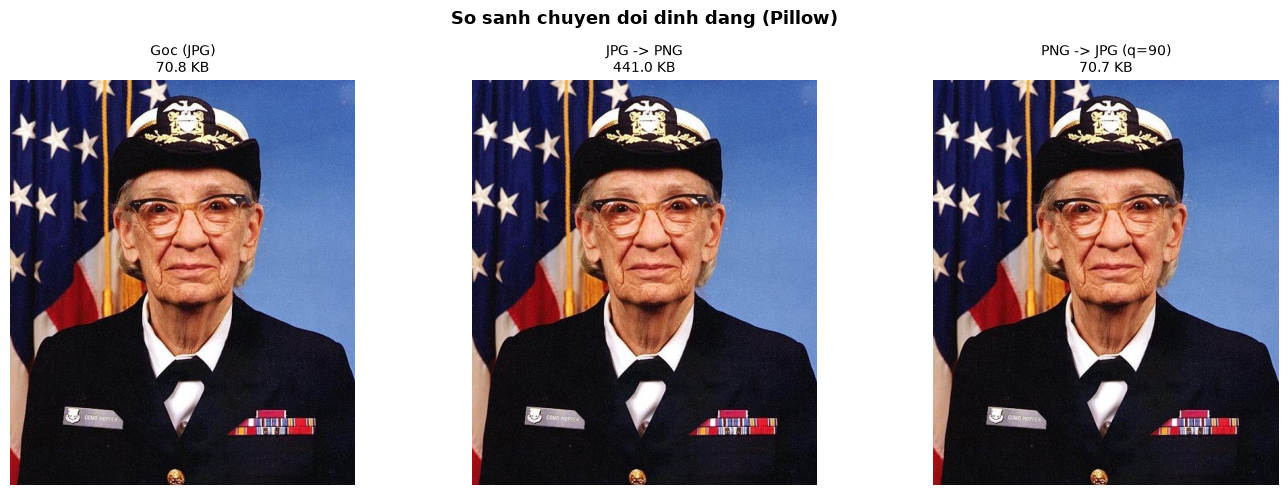

Da luu: format_comparison.png


In [9]:
stem = SAMPLE_JPG.stem
img_orig  = Image.open(SAMPLE_JPG)
img_pconv = Image.open(OUTPUT_DIR / (stem + '_converted.png'))
img_jconv = Image.open(OUTPUT_DIR / (stem + '_converted_back.jpg'))

size_jpg = SAMPLE_JPG.stat().st_size / 1024
size_png = (OUTPUT_DIR / (stem + '_converted.png')).stat().st_size / 1024
size_j2  = (OUTPUT_DIR / (stem + '_converted_back.jpg')).stat().st_size / 1024

labels = [
    f'Goc (JPG)\n{size_jpg:.1f} KB',
    f'JPG -> PNG\n{size_png:.1f} KB',
    f'PNG -> JPG (q=90)\n{size_j2:.1f} KB',
]
images = [img_orig, img_pconv, img_jconv]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, im, lbl in zip(axes, images, labels):
    ax.imshow(im)
    ax.set_title(lbl, fontsize=10)
    ax.axis('off')
plt.suptitle('So sanh chuyen doi dinh dang (Pillow)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'format_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Da luu: format_comparison.png')


---
## 6. Chuyển đổi hàng loạt (batch): JPG → PNG

In [10]:
demo_files = sorted(INPUT_DIR.glob('0*.jpg'))[:5]
BATCH_OUT = OUTPUT_DIR / 'batch_png'
BATCH_OUT.mkdir(parents=True, exist_ok=True)
print(f'Batch convert {len(demo_files)} anh: JPG -> PNG')
for src in demo_files:
    dst = BATCH_OUT / (src.stem + '.png')
    convert_format_pillow(src, dst)
    print(f'  {src.name:45s} -> {dst.name}')
print(f'Da luu vao: {BATCH_OUT}')


Batch convert 5 anh: JPG -> PNG
  01_portrait_grace_hopper.jpg                  -> 01_portrait_grace_hopper.png


  02_portrait_astronaut.jpg                     -> 02_portrait_astronaut.png
  03_portrait_hacker.jpg                        -> 03_portrait_hacker.png


  04_animal_cheetah_01.jpg                      -> 04_animal_cheetah_01.png


  05_animal_cheetah_02.jpg                      -> 05_animal_cheetah_02.png
Da luu vao: E:\XỬ LÍ THỊ GIÁC MÁY TÍNH\Computer-Vision-Group-2\lab_1\data\output\batch_png


---
## 7. So sánh Pillow và OpenCV

### 7.1 Cách đọc ảnh

In [11]:
img_pil = pillow_open(SAMPLE_JPG)
print('=== Pillow ===')
print(f'  type   : {type(img_pil)}')
print(f'  .size  : {img_pil.size}  (width, height)')
print(f'  .mode  : {img_pil.mode}')
print(f'  .format: {img_pil.format}')
print()
img_cv = cv2_open(SAMPLE_JPG)
print('=== OpenCV ===')
print(f'  type   : {type(img_cv)}')
print(f'  .shape : {img_cv.shape}  (height, width, channels)')
print(f'  .dtype : {img_cv.dtype}')
print('  Kenh mau: BGR (Blue-Green-Red)')


=== Pillow ===
  type   : <class 'PIL.JpegImagePlugin.JpegImageFile'>
  .size  : (512, 600)  (width, height)
  .mode  : RGB
  .format: JPEG

=== OpenCV ===
  type   : <class 'numpy.ndarray'>
  .shape : (600, 512, 3)  (height, width, channels)
  .dtype : uint8
  Kenh mau: BGR (Blue-Green-Red)


### 7.2 Thứ tự kênh màu: RGB (Pillow) vs BGR (OpenCV)

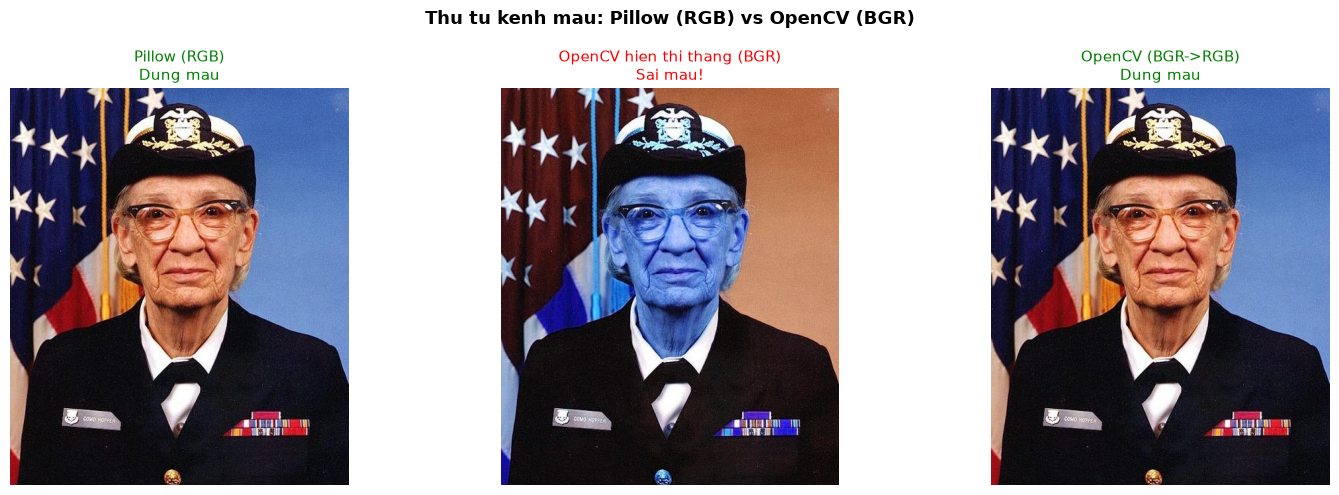

Da luu: color_channel_comparison.png


In [12]:
arr_pil    = np.array(img_pil)
arr_cv_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
arr_cv_raw = img_cv

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(arr_pil)
axes[0].set_title('Pillow (RGB)\nDung mau', fontsize=11, color='green')
axes[1].imshow(arr_cv_raw)
axes[1].set_title('OpenCV hien thi thang (BGR)\nSai mau!', fontsize=11, color='red')
axes[2].imshow(arr_cv_rgb)
axes[2].set_title('OpenCV (BGR->RGB)\nDung mau', fontsize=11, color='green')
for ax in axes: ax.axis('off')
plt.suptitle('Thu tu kenh mau: Pillow (RGB) vs OpenCV (BGR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'color_channel_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Da luu: color_channel_comparison.png')


### 7.3 Độ chính xác pixel

In [13]:
diff = np.abs(arr_pil.astype(int) - arr_cv_rgb.astype(int))
print(f'Max pixel difference  : {diff.max()}')
print(f'Mean pixel difference : {diff.mean():.4f}')
print(f'Pixel arrays identical: {np.array_equal(arr_pil, arr_cv_rgb)}')
print('-> Sai khac nho co the do JPEG decoding khac nhau giua cac thu vien.')


Max pixel difference  : 0
Mean pixel difference : 0.0000
Pixel arrays identical: True
-> Sai khac nho co the do JPEG decoding khac nhau giua cac thu vien.


### 7.4 Benchmark tốc độ đọc ảnh

=== Benchmark (20 lan lap) ===
  Pillow : 2.732 ms / lan
  OpenCV : 2.177 ms / lan
  Winner : OpenCV


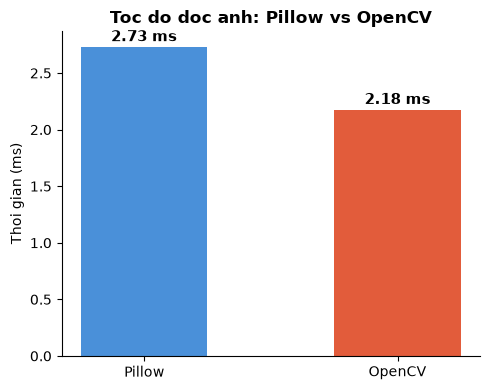

Da luu: benchmark_bar.png


In [14]:
bench = benchmark_read(SAMPLE_JPG, n_runs=20)
print('=== Benchmark (20 lan lap) ===')
print('  Pillow : {:.3f} ms / lan'.format(bench['pillow_ms']))
print('  OpenCV : {:.3f} ms / lan'.format(bench['opencv_ms']))
print('  Winner : {}'.format(bench['winner']))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Pillow', 'OpenCV'], [bench['pillow_ms'], bench['opencv_ms']],
              color=['#4A90D9', '#E25C3B'], width=0.5)
for bar, val in zip(bars, [bench['pillow_ms'], bench['opencv_ms']]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            '{:.2f} ms'.format(val), ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Thoi gian (ms)')
ax.set_title('Toc do doc anh: Pillow vs OpenCV', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'benchmark_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print('Da luu: benchmark_bar.png')


### 7.5 Bảng so sánh tổng hợp

| Tiêu chí | **Pillow** | **OpenCV** |
|---|---|---|
| Cách đọc | `Image.open(path)` | `cv2.imread(path)` |
| Kiểu trả về | `PIL.Image.Image` | `numpy.ndarray` |
| Thứ tự kênh | **RGB** | **BGR** |
| Kích thước | `.size` → `(width, height)` | `.shape` → `(height, width, ch)` |
| Lazy loading | ✅ Có | ❌ Không |
| Hỗ trợ video | ❌ Không | ✅ Có (`VideoCapture`) |
| Thao tác CV | Cơ bản | Phong phú |
| Phù hợp cho | Xử lý file ảnh, web | Computer Vision, real-time |


---
## 8. Kiểm tra nhiều ảnh cùng lúc

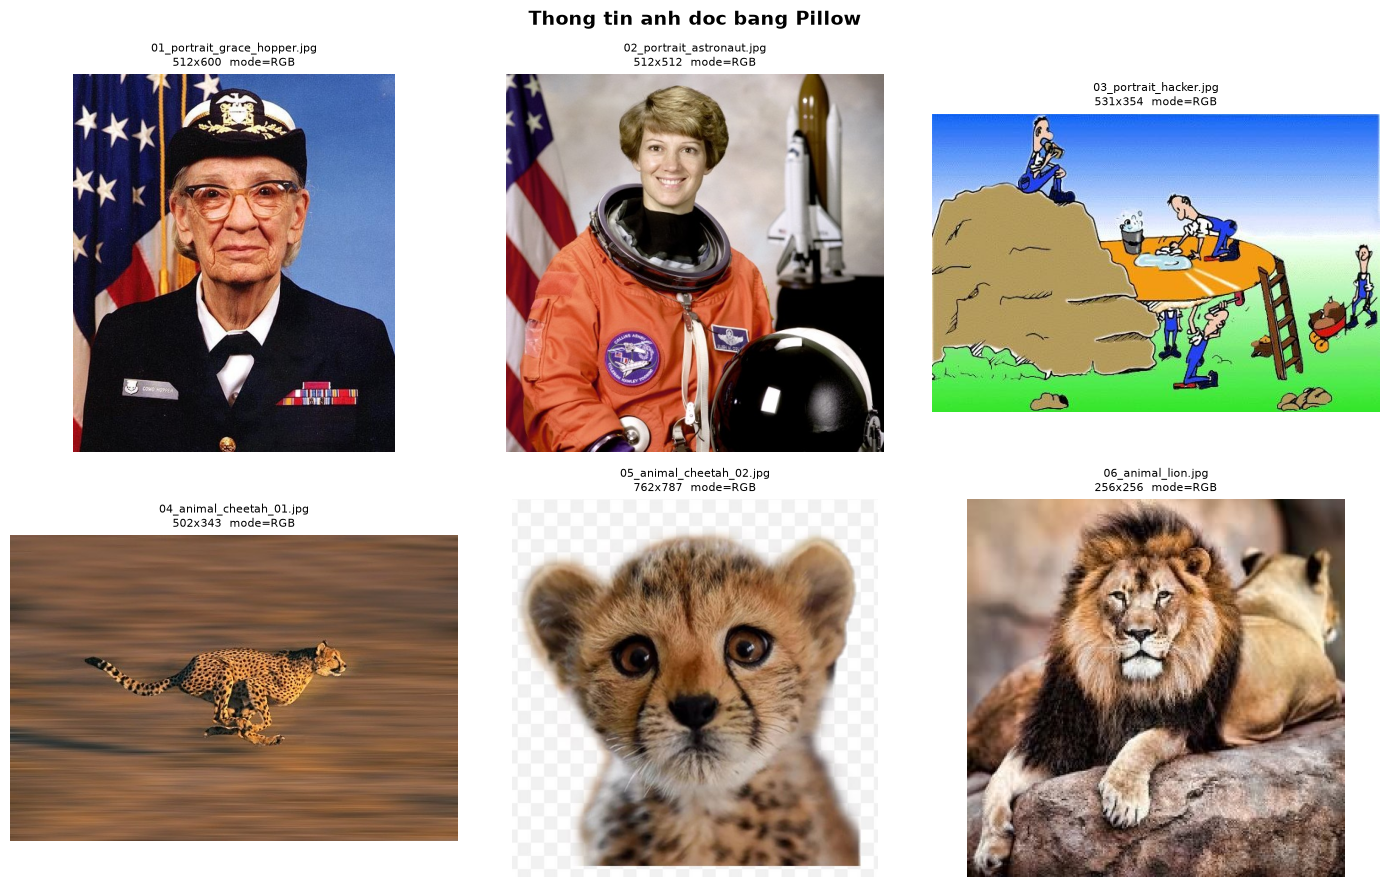

Da luu: multi_image_info.png


In [15]:
sample_imgs = sorted(INPUT_DIR.glob('0*.jpg'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for ax, p in zip(axes, sample_imgs):
    im = pillow_open(p)
    ax.imshow(im)
    ax.set_title('{0}\n{1}x{2}  mode={3}'.format(p.name, im.width, im.height, im.mode), fontsize=8)
    ax.axis('off')
plt.suptitle('Thong tin anh doc bang Pillow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multi_image_info.png', dpi=120, bbox_inches='tight')
plt.show()
print('Da luu: multi_image_info.png')


---
## 9. Tổng kết – Danh sách file output

In [16]:
print('Output DIR:', OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        rel = f.relative_to(OUTPUT_DIR)
        print('  {:<50s}  {:>8.1f} KB'.format(str(rel), f.stat().st_size/1024))
print()
print('Notebook hoan thanh – Run All khong loi!')


Output DIR: E:\XỬ LÍ THỊ GIÁC MÁY TÍNH\Computer-Vision-Group-2\lab_1\data\output
  .gitkeep                                                 0.0 KB
  01_portrait_grace_hopper_converted.png                 441.0 KB
  01_portrait_grace_hopper_converted_back.jpg             70.7 KB
  02_astronaut_enhanced_lab.png                          489.0 KB
  02_astronaut_gray.png                                  148.2 KB
  02_astronaut_hsv.png                                   400.4 KB
  02_astronaut_lab.png                                   317.8 KB
  02_flower_segmented.png                                129.6 KB
  02_portrait_astronaut_gray.png                         148.2 KB
  batch_png\01_portrait_grace_hopper.png                 441.0 KB
  batch_png\02_portrait_astronaut.png                    345.2 KB
  batch_png\03_portrait_hacker.png                       264.1 KB
  batch_png\04_animal_cheetah_01.png                     167.5 KB
  batch_png\05_animal_cheetah_02.png                     467.

---
## 10. Tóm tắt kiến thức

```
PILLOW CHEAT SHEET
  Mo anh           : img = Image.open('file.jpg')
  Kich thuoc        : img.size   -> (width, height)
  Chieu rong        : img.width  (so pixel ngang)
  Chieu cao         : img.height (so pixel doc)
  Che do mau        : img.mode   -> RGB / RGBA / L
  Dinh dang         : img.format -> JPEG / PNG
  Luu / chuyen doi  : img.save('out.png')
  Sang NumPy        : arr = np.array(img)  -> (H, W, C)
```
